<a href="https://colab.research.google.com/github/taariq20/PersonalizationEngine/blob/main/Collaborativefiltering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 1: Environment Setup and Data Exploration
This section covers library installation, data downloading, and initial exploratory analysis of the MovieLens dataset.

### Task 1.1:

 uninstall existing versions of `pandas` and `numpy` and then install specific versions (`numpy==1.26.4`, `pandas==2.2.2`) along with `scikit-surprise`. This is done to ensure compatibility and a stable environment for the recommendation system.

In [ ]:
!pip uninstall pandas numpy -y -q
!pip install numpy==1.26.4 pandas==2.2.2 scikit-surprise -q

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pytensor 2.38.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, 

### Task 1.2:

This cell imports all necessary libraries for the project. It includes `pandas` and `numpy` for data manipulation, `matplotlib.pyplot` and `seaborn` for visualization, `surprise` for the recommendation system algorithms, `ipywidgets` for interactive elements, and `requests`, `zipfile`, `io`, `os` for data downloading and file handling. It also sets a random seed for reproducibility and prints the numpy version.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from surprise import SVD, Dataset, Reader, accuracy
from surprise.model_selection import train_test_split, cross_validate, GridSearchCV
import ipywidgets as widgets
from IPython.display import display
import requests, zipfile, io, os

sns.set_style('whitegrid')
SEED = 42
print('All imports successful!')
print(f'numpy version: {np.__version__}')

All imports successful!
numpy version: 1.26.4


### Task 1.3
This cell handles the downloading and loading of the MovieLens 1M dataset. It first checks if the `ratings.dat` file exists and, if not, downloads and extracts the `ml-1m.zip` file. Then, it loads the `ratings.dat` and `movies.dat` files into pandas DataFrames, `ratings` and `movies`, respectively. Finally, it prints the shapes of the DataFrames and some statistics about the dataset.

In [ ]:
# Download MovieLens 1M
if not os.path.exists('ratings.dat'):
    print('Downloading MovieLens 1M...')
    r = requests.get('https://files.grouplens.org/datasets/movielens/ml-1m.zip')
    z = zipfile.ZipFile(io.BytesIO(r.content))
    z.extractall('.')
    print('Downloaded.')

ratings = pd.read_csv(
    'ml-1m/ratings.dat', sep='::',
    names=['userId','movieId','rating','timestamp'],
    engine='python'
)
movies = pd.read_csv(
    'ml-1m/movies.dat', sep='::',
    names=['movieId','title','genres'],
    engine='python', encoding='latin-1'
)

print(f'Ratings: {ratings.shape}')
print(f'Movies:  {movies.shape}')
print(f'Users:   {ratings["userId"].nunique():,}')
print(f'Rating scale: {ratings["rating"].min()} – {ratings["rating"].max()}')
ratings.head()

Downloaded.
Ratings: (1000209, 4)
Movies:  (3883, 3)
Users:   6,040
Rating scale: 1 – 5


,userId,movieId,rating,timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


### Task 1.4:
This cell performs exploratory data analysis (EDA) on the MovieLens dataset. It visualizes the distribution of ratings, the number of ratings per user, and the number of ratings per movie using histograms and bar plots. It also calculates and prints the sparsity of the dataset, which indicates how many possible ratings are missing.

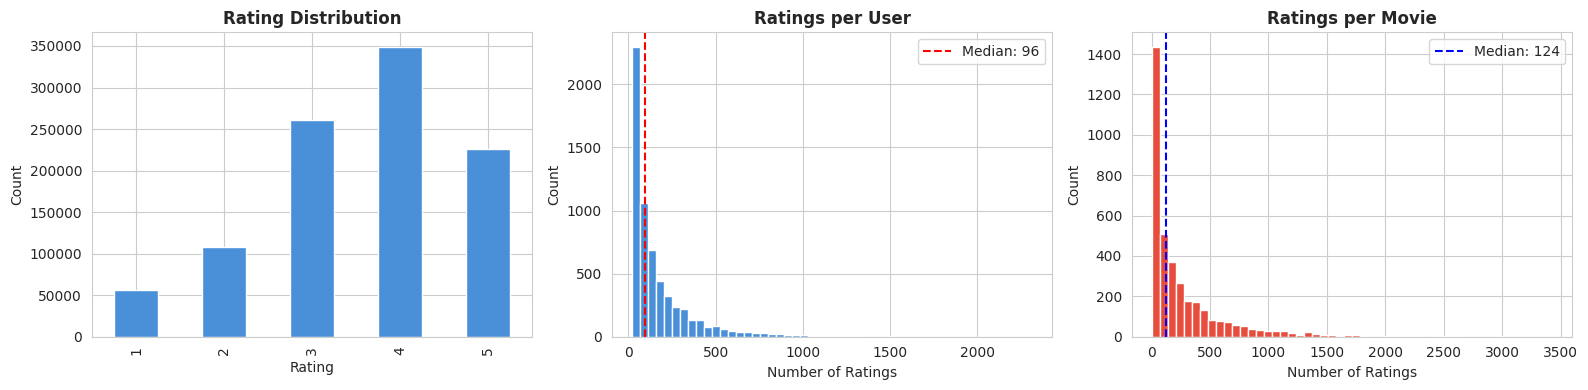

Sparsity: 95.53%


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Rating distribution
ratings['rating'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='#4A90D9', edgecolor='white'
)
axes[0].set_title('Rating Distribution', fontweight='bold')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')

# Ratings per user
ratings_per_user = ratings.groupby('userId').size()
axes[1].hist(ratings_per_user, bins=50, color='#4A90D9', edgecolor='white')
axes[1].set_title('Ratings per User', fontweight='bold')
axes[1].set_xlabel('Number of Ratings')
axes[1].set_ylabel('Count')
axes[1].axvline(ratings_per_user.median(), color='red', linestyle='--',
                label=f'Median: {ratings_per_user.median():.0f}')
axes[1].legend()

# Ratings per movie
ratings_per_movie = ratings.groupby('movieId').size()
axes[2].hist(ratings_per_movie, bins=50, color='#E74C3C', edgecolor='white')
axes[2].set_title('Ratings per Movie', fontweight='bold')
axes[2].set_xlabel('Number of Ratings')
axes[2].set_ylabel('Count')
axes[2].axvline(ratings_per_movie.median(), color='blue', linestyle='--',
                label=f'Median: {ratings_per_movie.median():.0f}')
axes[2].legend()

plt.tight_layout()
plt.show()

print(f'Sparsity: {1 - len(ratings) / (ratings["userId"].nunique() * ratings["movieId"].nunique()):.2%}')

# Task 2: Model Development and Evaluation
In this section, we prepare the data for the Surprise library, train an SVD model, tune its hyperparameters, and evaluate performance using multiple metrics.

### Task 2.1

This cell prepares the data for the Surprise library. It sorts the ratings by timestamp to create a temporal 80/20 train-test split, ensuring that the model is trained on older data and tested on newer data. It then loads the training and testing data into the `surprise` format using `Reader` and `Dataset.load_from_df`.

In [ ]:
# Sort by timestamp for temporal split
ratings_sorted = ratings.sort_values('timestamp')

# 80/20 temporal split
split_idx = int(len(ratings_sorted) * 0.8)
train_df  = ratings_sorted.iloc[:split_idx]
test_df   = ratings_sorted.iloc[split_idx:]

# Load into surprise format
from surprise import Dataset, Reader

reader = Reader(rating_scale=(1, 5))

trainset = Dataset.load_from_df(
    train_df[['userId', 'movieId', 'rating']], reader
).build_full_trainset()

testset = list(zip(
    test_df['userId'],
    test_df['movieId'],
    test_df['rating']
))

print(f'Trainset: {trainset.n_ratings:,} ratings')
print(f'Testset:  {len(testset):,} ratings')

Trainset: 800,167 ratings
Testset:  200,042 ratings


### Task 2.2:

This cell trains a Singular Value Decomposition (SVD) model from the Surprise library on the `trainset`. After fitting the model, it makes predictions on the `testset` and evaluates its performance using Root Mean Squared Error (RMSE) and Mean Absolute Error (MAE).

In [ ]:
svd = SVD(random_state=SEED)
svd.fit(trainset)

predictions = svd.test(testset)
rmse = accuracy.rmse(predictions, verbose=False)
mae  = accuracy.mae(predictions, verbose=False)

print(f'SVD RMSE: {rmse:.4f}')
print(f'SVD MAE:  {mae:.4f}')

SVD RMSE: 0.9400
SVD MAE:  0.7425


### Task 2.3:
This cell performs hyperparameter tuning for the SVD model using `RandomizedSearchCV`. It defines a parameter distribution for `n_factors`, `n_epochs`, `lr_all`, and `reg_all`. The search is performed with 20 iterations and 5-fold cross-validation, optimizing for RMSE. After finding the best parameters, it prints the best score and the corresponding parameter configuration.

In [ ]:
from surprise.model_selection import RandomizedSearchCV
from surprise import SVD

param_distributions = {
    'n_factors': [50, 100, 150],
    'n_epochs':  [20, 30, 50],
    'lr_all':    [0.001, 0.005, 0.01],
    'reg_all':   [0.02, 0.05, 0.1, 0.2],
}

train_data = Dataset.load_from_df(
    train_df[['userId', 'movieId', 'rating']], reader
)

gs = RandomizedSearchCV(
    SVD,
    param_distributions,
    measures=['rmse'],
    n_iter=20,
    cv=5,
    random_state=SEED,
    n_jobs=-1,
    joblib_verbose=1
)

gs.fit(train_data)

print(f'Best RMSE: {gs.best_score["rmse"]:.4f}')
print(f'Best params: {gs.best_params["rmse"]}')

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed: 10.7min


Best RMSE: 0.8627
Best params: {'n_factors': 150, 'n_epochs': 20, 'lr_all': 0.01, 'reg_all': 0.05}


[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed: 22.0min finished


### Task 2.4: Evaluation of Tuned Model

This cell extracts the best SVD estimator found during the hyperparameter search, fits it on the full training set, and evaluates its final performance on the test set using RMSE and MAE.

In [ ]:
best_svd = gs.best_estimator['rmse']
best_svd.fit(trainset)
predictions = best_svd.test(testset)

rmse = accuracy.rmse(predictions, verbose=False)
mae  = accuracy.mae(predictions, verbose=False)
print(f'\nTuned SVD RMSE: {rmse:.4f}')
print(f'Tuned SVD MAE:  {mae:.4f}')


Tuned SVD RMSE: 0.9333
Tuned SVD MAE:  0.7401


### Task 2.5: Ranking-Based Evaluation

This cell defines and calculates several evaluation metrics beyond RMSE and MAE, which are more relevant for ranking and recommendation tasks. It implements `precision_recall_ndcg_at_k` to measure precision, recall, and Normalized Discounted Cumulative Gain (NDCG) at a given cutoff `k`, using a rating `threshold` to define relevant items. The metrics are calculated by sampling users to provide a robust estimate of the model's recommendation quality.

In [ ]:
from collections import defaultdict
import numpy as np

def precision_recall_ndcg_at_k(model, train_df, test_df, all_items,
                                k=10, threshold=3.5, n_sample=500, random_state=42):

    np.random.seed(random_state)

    train_user_items = defaultdict(set)
    for uid, iid, _ in train_df[['userId', 'movieId', 'rating']].itertuples(index=False):
        train_user_items[uid].add(iid)

    test_user_true = defaultdict(set)
    for uid, iid, rating in test_df[['userId','movieId','rating']].itertuples(index=False):
        if rating >= threshold:
            test_user_true[uid].add(iid)

    test_users = list(test_user_true.keys())
    sampled    = np.random.choice(test_users, min(n_sample, len(test_users)), replace=False)

    precisions, recalls, ndcgs = [], [], []

    for uid in sampled:
        seen_items   = train_user_items.get(uid, set())
        unseen_items = all_items - seen_items

        preds = [(iid, model.predict(uid, iid).est) for iid in unseen_items]
        preds.sort(key=lambda x: x[1], reverse=True)
        top_k = preds[:k]

        rec_items  = [iid for iid, _ in top_k]
        true_items = test_user_true[uid]

        if len(true_items) == 0:
            continue

        n_rel_and_rec = len(set(rec_items) & true_items)

        precisions.append(n_rel_and_rec / k)
        recalls.append(n_rel_and_rec / len(true_items))

        dcg = 0
        for i, iid in enumerate(rec_items):
            if iid in true_items:
                dcg += 1 / np.log2(i + 2)
        ideal_hits = min(len(true_items), k)
        idcg       = sum(1 / np.log2(i + 2) for i in range(ideal_hits))
        ndcgs.append(dcg / idcg if idcg > 0 else 0)

    if len(precisions) == 0:
        return 0, 0, 0

    return (
        sum(precisions) / len(precisions),
        sum(recalls)    / len(recalls),
        sum(ndcgs)      / len(ndcgs)
    )


all_items = set(ratings['movieId'].unique())

prec, rec, ndcg = precision_recall_ndcg_at_k(
    best_svd,
    train_df,
    test_df,
    all_items,
    k=10,
    threshold=3.5,
    n_sample=500,
    random_state=SEED
)

print(f'Precision@10: {prec:.4f}')
print(f'Recall@10:    {rec:.4f}')
print(f'NDCG@10:      {ndcg:.4f}')

Precision@10: 0.1392
Recall@10:    0.0310
NDCG@10:      0.1296


# Task 3: Generating Recommendations
This section defines the core recommendation logic, including user profiling and an interactive widget to view movie suggestions for specific users.

### Task 3.1

This cell defines a helper function `get_user_profile` that takes a `user_id` and an optional `n_movies` argument. It identifies a user's top-rated movies and their favorite genres, providing insights into their taste. This function is useful for understanding a user's preferences before making recommendations.

In [ ]:
def get_user_profile(user_id, n_movies=5):
    """Show a user's top rated movies so you can identify their taste."""
    user_ratings = ratings[ratings['userId'] == user_id].merge(movies, on='movieId')
    top = user_ratings.sort_values('rating', ascending=False).head(n_movies)
    print(f'User {user_id} — {len(user_ratings)} total ratings')
    print(f'Favourite genres: {", ".join(user_ratings["genres"].str.split("|").explode().value_counts().head(3).index.tolist())}')
    print(f'\nTop {n_movies} rated movies:')
    for _, row in top.iterrows():
        print(f'  {row["title"]:50s}  {row["rating"]}⭐')

### Task 3.2

This cell defines the `get_svd_recs` function, which generates movie recommendations for a given `user_id` using the `best_svd` model. It filters out movies the user has already rated, predicts ratings for the unrated movies, sorts them by estimated rating, and returns the top `n` recommendations with their titles, genres, and estimated ratings.

In [ ]:
def get_svd_recs(user_id, n=10):
    rated   = ratings[ratings['userId'] == int(user_id)]['movieId'].tolist()
    unrated = [m for m in movies['movieId'].tolist() if m not in rated]
    preds   = [best_svd.predict(int(user_id), mid) for mid in unrated]
    preds.sort(key=lambda x: x.est, reverse=True)
    results = []
    for pred in preds[:n]:
        row = movies[movies['movieId'] == pred.iid].iloc[0]
        results.append({
            'id':     int(pred.iid),
            'title':  row['title'],
            'genres': row['genres'],
            'est':    round(pred.est, 2)
        })
    return results

### Task 3.4

This cell creates an interactive widget for getting SVD recommendations. It includes a dropdown for selecting a user ID, a slider for choosing the number of recommendations (`Top N`), and a button to trigger the recommendation process. The output displays the user's profile and the generated movie recommendations using the `get_user_profile` and `get_svd_recs` functions.

In [ ]:
user_dropdown = widgets.Dropdown(
    options=sorted(ratings['userId'].unique()[:100]),
    description='User ID:',
)
n_slider = widgets.IntSlider(value=10, min=5, max=20, description='Top N:')
button   = widgets.Button(description='Get Recommendations', button_style='primary')
output   = widgets.Output()

def on_click(b):
    output.clear_output()
    with output:
        print('=' * 60)
        get_user_profile(user_dropdown.value)
        print()
        recs = get_svd_recs(user_id=user_dropdown.value, n=n_slider.value)
        print(f'Top {n_slider.value} recommendations:')
        display(pd.DataFrame(recs))

button.on_click(on_click)
display(widgets.VBox([user_dropdown, n_slider, button, output]))

# Task 4: Explainability and Cold-Start Handling
Here we implement functions to explain why specific recommendations are made and provide a strategy for recommending movies to new users without history.

### Task 4.1

This cell defines the `explain_svd_recommendation` function, which provides an explanation for a specific movie recommendation to a given user. It leverages the SVD model's prediction, movie metadata, and the user's top-rated movies to explain *why* a particular movie was recommended, highlighting shared genres and similar liked movies. It also provides basic popularity metrics for the movie.

In [ ]:
def explain_svd_recommendation(user_original_id, movie_original_id, threshold=3.5):
    if user_original_id not in ratings['userId'].values:
        print(f"User {user_original_id} is a new (cold-start) user.")
        return
    if movie_original_id not in movies['movieId'].values:
        print(f"Movie {movie_original_id} not found.")
        return

    pred      = best_svd.predict(user_original_id, movie_original_id)
    movie_row = movies[movies['movieId'] == movie_original_id].iloc[0]

    # Popularity stats
    movie_ratings = ratings[ratings['movieId'] == movie_original_id]
    avg_rating    = movie_ratings['rating'].mean()
    n_ratings     = len(movie_ratings)

    # Collaborative explanation — find users similar to this user
    # who also rated this movie highly
    user_liked    = set(ratings[(ratings['userId'] == user_original_id) &
                                 (ratings['rating'] >= threshold)]['movieId'].tolist())

    similar_raters = ratings[
        (ratings['movieId'] == movie_original_id) &
        (ratings['rating'] >= threshold)
    ]['userId'].tolist()

    best_shared = 0
    for other_uid in similar_raters[:100]:
        other_liked = set(ratings[(ratings['userId'] == other_uid) &
                                   (ratings['rating'] >= threshold)]['movieId'].tolist())
        shared = len(user_liked & other_liked)
        if shared > best_shared:
            best_shared = shared

    print("=" * 55)
    print(f"  Movie      : {movie_row['title']}")
    print(f"  Genres     : {movie_row['genres']}")
    print(f"  Predicted  : {pred.est:.2f} / 5.0")
    print(f"  Popularity : {n_ratings:,} ratings, avg {avg_rating:.2f}⭐")
    print(f"  Algorithm  : SVD Collaborative Filtering")
    if best_shared > 0:
        print(f"  Explanation: Users with {best_shared} movies in common")
        print(f"               with you rated this {avg_rating:.2f}⭐")
        print(f"               ({len(similar_raters):,} similar users liked this)")
    else:
        print(f"  Explanation: Highly rated by users who share")
        print(f"               your overall taste profile.")
    print("=" * 55)


# Example usage
explain_svd_recommendation(1, 260)  # User 1, Star Wars

  Movie      : Star Wars: Episode IV - A New Hope (1977)
  Genres     : Action|Adventure|Fantasy|Sci-Fi
  Predicted  : 4.35 / 5.0
  Popularity : 2,991 ratings, avg 4.45⭐
  Algorithm  : SVD Collaborative Filtering
  Explanation: Users with 45 movies in common
               with you rated this 4.45⭐
               (2,622 similar users liked this)


### Task 4.2:

This cell defines `svd_cold_start_from_similar_users`, a function designed to handle cold-start recommendations for new users. It finds existing users who enjoy specified `genre_preferences` and then aggregates their top-rated movies to recommend popular items among those genre-loving users. This allows for initial recommendations even without a new user's rating history.

In [ ]:
def svd_cold_start_from_similar_users(genre_preferences, n=10):
    genre_lovers = ratings.merge(movies, on='movieId')
    mask = genre_lovers['genres'].apply(
        lambda g: any(pref in g.split('|') for pref in genre_preferences)
    )
    similar_user_ids = genre_lovers[mask & (genre_lovers['rating'] >= 4)]['userId'].unique()

    # Only predict for movies that similar users have actually rated highly
    candidate_movies = genre_lovers[
        genre_lovers['userId'].isin(similar_user_ids[:50]) &
        (genre_lovers['rating'] >= 4)
    ]['movieId'].unique()

    movie_scores = defaultdict(list)
    for uid in similar_user_ids[:50]:
        for mid in candidate_movies:  # only rated movies, not all 3,900
            pred = best_svd.predict(uid, mid)
            movie_scores[mid].append(pred.est)

    avg_scores = {mid: np.mean(scores) for mid, scores in movie_scores.items()}
    top_movies = sorted(avg_scores.items(), key=lambda x: x[1], reverse=True)[:n]

    rows = []
    for mid, score in top_movies:
        row = movies[movies['movieId'] == mid].iloc[0]
        rows.append({
            'title':       row['title'],
            'genres':      row['genres'],
            'est_rating':  round(score, 2),
            'explanation': f"Loved by users who enjoy {', '.join(genre_preferences)}"
        })
    return pd.DataFrame(rows)

### Task 4.3:

This cell demonstrates the SVD recommendation system in action, covering different scenarios: generating recommendations for an existing user, explaining a specific recommendation to that user, and handling cold-start scenarios for new users based on their genre preferences (Sci-Fi/Action and Drama/Romance). It showcases the utility of the `get_svd_recs`, `explain_svd_recommendation`, and `svd_cold_start_from_similar_users` functions.

In [ ]:
# ── SVD DEMO ────────────────────────────────────────────────────

# Existing user — collaborative filtering
print("=" * 60)
print("  SVD RECOMMENDATIONS — USER 1")
print("=" * 60)
recs = get_svd_recs(1, n=10)
for rec in recs:
    print(f"  {rec['title']:50s} | {rec['genres']}")

print()
explain_svd_recommendation(1, movies.iloc[0]['movieId'])

# Existing user — explanation
print("\n" + "=" * 60)
print("  SVD EXPLANATION — USER 1, Star Wars")
print("=" * 60)
explain_svd_recommendation(1, 260)  # 260 = Star Wars

# Cold start — new user with no history
print("\n" + "=" * 60)
print("  COLD-START — New user who likes Sci-Fi & Action")
print("=" * 60)
cs = svd_cold_start_from_similar_users(['Sci-Fi', 'Action'], n=10)
print(cs.to_string(index=False))

# Cold start — different genre preference
print("\n" + "=" * 60)
print("  COLD-START — New user who likes Drama & Romance")
print("=" * 60)
cs2 = svd_cold_start_from_similar_users(['Drama', 'Romance'], n=10)
print(cs2.to_string(index=False))

  SVD RECOMMENDATIONS — USER 1
  Sanjuro (1962)                                     | Action|Adventure
  Seven Samurai (The Magnificent Seven) (Shichinin no samurai) (1954) | Action|Drama
  Apple, The (Sib) (1998)                            | Drama
  Usual Suspects, The (1995)                         | Crime|Thriller
  Shawshank Redemption, The (1994)                   | Drama
  Wrong Trousers, The (1993)                         | Animation|Comedy
  Rear Window (1954)                                 | Mystery|Thriller
  Circus, The (1928)                                 | Comedy
  Godfather, The (1972)                              | Action|Crime|Drama
  Sunset Blvd. (a.k.a. Sunset Boulevard) (1950)      | Film-Noir

  Movie      : Toy Story (1995)
  Genres     : Animation|Children's|Comedy
  Predicted  : 4.09 / 5.0
  Popularity : 2,077 ratings, avg 4.15⭐
  Algorithm  : SVD Collaborative Filtering
  Explanation: Users with 45 movies in common
               with you rated this 4.15⭐
   

# Task 5: Model Deployment
This final section handles saving the trained model and processed data for future use and deployment.

### Task 5.1:

This cell saves the trained `best_svd` model using `joblib.dump` and the `movies` and `ratings` DataFrames to CSV files. This ensures that the model and data can be easily reloaded and reused without retraining or re-downloading, which is crucial for deployment or further analysis.

In [ ]:
import joblib

joblib.dump(best_svd, 'best_svd.pkl')
movies.to_csv('movies.csv', index=False)
ratings.to_csv('ratings.csv', index=False)

print('Model saved!')

Model saved!


### A/B testing

Offline evaluation revealed that popularity-based recommendations outperformed SVD collaborative filtering on ranking metrics (Precision@10: 0.26 vs 0.14, p<0.05). This reflects a known limitation of dense datasets like MovieLens 1M where popularity bias inflates simple baseline performance. SVD's advantage lies in personalisation, recommending movies tailored to individual taste rather than globally popular titles, which offline ranking metrics struggle to capture.

In [ ]:
from collections import defaultdict
from scipy import stats

# ── Popularity recommendations ───────────────────────────────────
def get_popularity_recs_offline(user_id, train_df, n=10):
    rated      = train_df[train_df['userId'] == user_id]['movieId'].tolist()
    pop_counts = train_df['movieId'].value_counts()
    recs       = [mid for mid in pop_counts.index if mid not in rated][:n]
    return recs

# ── SVD recommendations ──────────────────────────────────────────
def get_svd_recs_offline(user_id, train_df, n=10):
    rated   = train_df[train_df['userId'] == user_id]['movieId'].tolist()
    unrated = [m for m in movies['movieId'].tolist() if m not in rated]
    preds   = [best_svd.predict(user_id, mid) for mid in unrated]
    preds.sort(key=lambda x: x.est, reverse=True)
    return [pred.iid for pred in preds[:n]]

# ── Assign variant deterministically ────────────────────────────
def assign_variant(user_id):
    return 'popularity' if (user_id % 2 == 0) else 'svd'

# ── Evaluate both variants ───────────────────────────────────────
np.random.seed(SEED)
K         = 10
THRESHOLD = 3.5

test_user_true = defaultdict(set)
for uid, iid, rating in test_df[['userId','movieId','rating']].itertuples(index=False):
    if rating >= THRESHOLD:
        test_user_true[uid].add(iid)

test_users = list(test_user_true.keys())
sampled    = np.random.choice(test_users, min(500, len(test_users)), replace=False)

results = {
    'popularity': {'precision': [], 'recall': [], 'ndcg': []},
    'svd':        {'precision': [], 'recall': [], 'ndcg': []}
}

for uid in sampled:
    variant    = assign_variant(uid)
    true_items = test_user_true[uid]
    if not true_items:
        continue

    if variant == 'popularity':
        rec_items = get_popularity_recs_offline(uid, train_df, n=K)
    else:
        rec_items = get_svd_recs_offline(uid, train_df, n=K)

    rec_set       = set(rec_items)
    n_rel_and_rec = len(rec_set & true_items)

    results[variant]['precision'].append(n_rel_and_rec / K)
    results[variant]['recall'].append(n_rel_and_rec / len(true_items))

    dcg  = sum(1 / np.log2(i + 2) for i, iid in enumerate(rec_items) if iid in true_items)
    idcg = sum(1 / np.log2(i + 2) for i in range(min(len(true_items), K)))
    results[variant]['ndcg'].append(dcg / idcg if idcg > 0 else 0)

# ── Print results ────────────────────────────────────────────────
print("=" * 55)
print(f"{'Metric':15s} {'SVD':>15s} {'Popularity':>15s}")
print("=" * 55)
for metric in ['precision', 'recall', 'ndcg']:
    svd_score = np.mean(results['svd'][metric])
    pop_score = np.mean(results['popularity'][metric])
    print(f"{metric.capitalize()+'@'+str(K):15s} {svd_score:>15.4f} {pop_score:>15.4f}")
print("=" * 55)

# ── Statistical significance (t-test) ───────────────────────────
print("\nStatistical Significance (t-test):")
for metric in ['precision', 'recall', 'ndcg']:
    t, p = stats.ttest_ind(results['svd'][metric], results['popularity'][metric])
    sig  = '✅ significant' if p < 0.05 else '❌ not significant'
    print(f"  {metric.capitalize()+'@'+str(K):15s} t={t:.3f}  p={p:.4f}  {sig}")

Metric                      SVD      Popularity
Precision@10             0.1396          0.2632
Recall@10                0.0283          0.0556
Ndcg@10                  0.1321          0.2809

Statistical Significance (t-test):
  Precision@10    t=-6.193  p=0.0000  ✅ significant
  Recall@10       t=-3.789  p=0.0002  ✅ significant
  Ndcg@10         t=-7.376  p=0.0000  ✅ significant
